# 1. Importando/Instalando bibliotecas

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, make_scorer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV

from sklearn.pipeline import Pipeline

from scipy.stats import randint, uniform

import sys

import joblib

# 2. Clonando el repositorio

In [ ]:
!git clone -b feature/model-training https://github.com/ezeperezds/Anemia-Prediction-System.git

Cloning into 'Anemia-Prediction-System'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 170 (delta 64), reused 135 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (170/170), 2.62 MiB | 10.46 MiB/s, done.
Resolving deltas: 100% (64/64), done.


In [ ]:
sys.path.append('/content/Anemia-Prediction-System/')

# 3. Importando los datos

In [ ]:
X_temp = pd.read_csv('/content/Anemia-Prediction-System/data/processed/X_temp.csv')
X_train = np.load('/content/Anemia-Prediction-System/data/processed/X_train.npy')
X_val = np.load('/content/Anemia-Prediction-System/data/processed/X_val.npy')

y_temp = np.load('/content/Anemia-Prediction-System/data/processed/y_temp.npy')
y_train = np.load('/content/Anemia-Prediction-System/data/processed/y_train.npy')
y_val = np.load('/content/Anemia-Prediction-System/data/processed/y_val.npy')

In [ ]:
from src.preprocessing.features import FeatureSelector

In [ ]:
from src.models.evaluate import show_metrics, show_confusion_matrix, show_cv_metrics, show_thresholds

In [ ]:
preprocessor = joblib.load('/content/Anemia-Prediction-System/models/preprocessor_pipeline.pkl')

In [ ]:
X_train.shape

(993, 8)

In [ ]:
X_val.shape

(214, 8)

# 4. Definiendo la métrica del problema

Antes de entrenar los modelos, es necesario definir las métricas que se utilizarán para evaluar su desempeño. Esta elección debe responder a las necesidades del problema y al tipo de errores que se desean minimizar.

En este proyecto, el objetivo principal es identificar correctamente a los pacientes con anemia. Debido a ello, los falsos negativos representan el error de mayor impacto, ya que implican clasificar como sano a un paciente que realmente presenta la enfermedad.

Por este motivo, la métrica principal será el `Recall`, ya que permite evaluar la capacidad del modelo para detectar correctamente los casos positivos.

Como métrica complementaria se utilizará el `F1-Score`, dado que considera el equilibrio entre `precision` y `recall`, proporcionando una evaluación más completa del desempeño del modelo.

Adicionalmente, durante la evaluación también se analizarán las métricas de `accuracy` y `precision`, con el fin de obtener una visión integral del comportamiento de cada algoritmo.

# 5. Modelos candidatos a evaluar

Con el objetivo de identificar el algoritmo que mejor se adapte al problema de clasificación, se evaluarán distintos modelos de Machine Learning ampliamente utilizados para clasificación binaria.

La selección incluye algoritmos de diferentes familias, lo que permitirá comparar enfoques basados en modelos lineales, árboles de decisión, métodos de ensamblado (ensemble learning), técnicas de boosting y máquinas de vectores de soporte.

Los modelos considerados para la etapa de evaluación son los siguientes:

* `Logistic Regression` (Baseline): utilizado como modelo de referencia por su simplicidad, interpretabilidad y amplio uso en problemas de clasificación.
* `Decision Tree Classifier`: modelo basado en árboles de decisión, capaz de capturar relaciones no lineales entre las variables.
* `Random Forest Classifier`: método de ensamblado que combina múltiples árboles de decisión para mejorar la capacidad de generalización y reducir el sobreajuste.
* `XGBoost Classifier`: algoritmo de Gradient Boosting reconocido por su alto desempeño en problemas de clasificación y competiciones de Machine Learning.
* `LightGBM Classifier`: implementación eficiente de Gradient Boosting diseñada para reducir los tiempos de entrenamiento y manejar conjuntos de datos de forma eficiente.
* `CatBoost Classifier`: algoritmo de Gradient Boosting optimizado para el tratamiento de variables categóricas y reconocido por su buen rendimiento con una configuración relativamente sencilla.
* `Support Vector Classifier` (SVC): algoritmo basado en máquinas de vectores de soporte, adecuado para problemas de clasificación donde existe una separación clara entre las clases.

Una vez entrenados, todos los modelos serán evaluados utilizando las métricas definidas previamente y bajo las mismas condiciones experimentales, con el objetivo de identificar el candidato que presente el mejor desempeño para el problema planteado.

# 6. Modelado

## 1. Baseline

In [ ]:
baseline_model = LogisticRegression(random_state=82, max_iter=1000, C=0.01)

baseline_model.fit(X_train, y_train)

LogisticRegression(C=0.01, max_iter=1000, random_state=82)

In [ ]:
y_pred_baseline = baseline_model.predict(X_val)

### 1.1 Evaluación de metricas

In [ ]:
log_metrics = show_metrics('logistic regresion', y_val, y_pred_baseline)
log_metrics

"logistic regresion metrics: {'accuracy': 0.92, 'precision': 0.9, 'recall': 0.92, 'f1-score': 0.91}"

La evaluación del modelo de regresión logistica realizada sobre el conjunto de validación retorno las siguientes métricas:

---

| Métrica   | Valor   | Interpretación       |
|---------- |------   |--------------|
| Accuracy  | 0.92    | El modelo clasifico correctamente el 92% de las muestras.       |
| Precision | 0.9    | De todas las predicciones positivas, el 90% corresponden realmente a casos positivos. |
| Recall    | 0.92    | El modelo clasifico correctamente el 92% de casos positivos del conjunto de datos.       |
| F1-Score  | 0.91    | El balance entre precisión y recall fue de un 91%, indicando un buen desempeño general considerando ambas métricas.       |


---

#### **Análisis**

El modelo obtuvo un recall del 92%, es decir, fue capaz de detectar correctamente el 92% de datos pertenecientes a la clase positiva. Considerando nuestro problema y la importancia que tiene detectar la clase positiva, este comportamiento del modelo es favorecedor.

Ademas, el modelo presento una precisión del 90%, indicando que la mayoria de las predicciones positivas realizadas por el modelo corresponden a pacientes con anemia. No obstante, existe una proporción de predicciones que fueron catalogadas como positivas, cuando estos no presentaban la enfermedad (falsos positivos).

### 1.2 Matriz de confusión

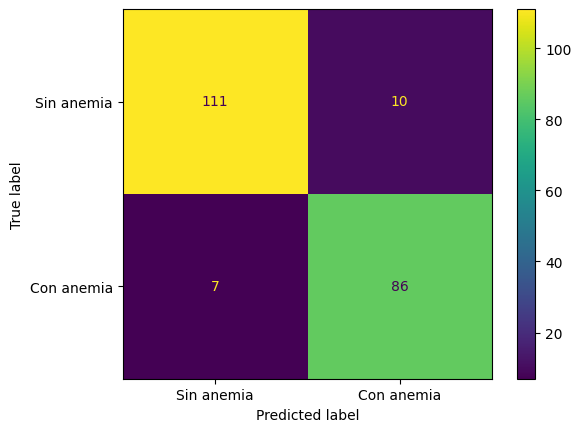

In [ ]:
confusion_matrix_lr = show_confusion_matrix(y_val, y_pred_baseline)
plt.show()

### Matriz de confusión

La matriz de confusión permite analizar el desempeño del modelo más allá de las métricas agregadas, identificando los tipos de errores cometidos en la clasificación.

---

El modelo obtuvo:

* 111 verdaderos negativos, clasificando correctamente pacientes sin anemia.
* 86 verdaderos positivos, identificando correctamente pacientes con anemia.
* 10 falsos positivos, donde pacientes sin anemia fueron clasificados como positivos.
* 7 falsos negativos, donde pacientes con anemia no fueron detectados.


### 1.3 Validación cruzada

In [ ]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=82, max_iter=1000, C=0.01))
])

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=82
)

In [ ]:
scores_lr = cross_validate(
    pipeline_lr,
    X_temp,
    y_temp,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ],
    return_train_score=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [ ]:
results_baseline = pd.DataFrame(scores_lr)

results_baseline

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,0.140707,0.030487,0.925620,0.885965,0.952830,0.918182
1,0.098395,0.074708,0.938017,0.959596,0.896226,0.926829
2,0.120739,0.121769,0.921162,0.864407,0.971429,0.914798
3,0.097543,0.163741,0.912863,0.868421,0.942857,0.904110
4,0.122889,0.223617,0.937759,0.932692,0.923810,0.928230


In [ ]:
metrics_cv_lr = show_cv_metrics(scores_lr)
metrics_cv_lr

{'accuracy': '0.9271 ± 0.0097',
 'precision': '0.9022 ± 0.0376',
 'recall': '0.9374 ± 0.0257',
 'f1': '0.9184 ± 0.0088'}

| Métrica   | Media ± Desviación estándar |
| --------- | --------------------------: |
| Accuracy  |         **0.9271 ± 0.0097** |
| Precision |         **0.9022 ± 0.0376** |
| Recall    |         **0.9374 ± 0.0257** |
| F1-Score  |         **0.9184 ± 0.0088** |


---

#### Análisis

Uno de los aspectos más destacados es la estabilidad del modelo. El `accuracy` `(0.9271 ± 0.0097)` y el `F1-score` `(0.9184 ± 0.0088)` presentan desviaciones estándar reducidas, lo que evidencia que el rendimiento del modelo varía muy poco entre las diferentes iteraciones de la validación cruzada. Esto sugiere que la Regresión Logística ofrece un comportamiento estable y reproducible frente a distintas particiones de los datos.

El `recall` promedio de `0.9374 ± 0.0257` indica que el modelo mantiene una elevada capacidad para detectar correctamente los casos positivos, mientras que la `precision` promedio de `0.9022 ± 0.0376` muestra que la mayoría de las predicciones positivas corresponden efectivamente a pacientes con anemia. En conjunto, ambas métricas reflejan un equilibrio adecuado entre la capacidad de detección y la fiabilidad de las predicciones.

En términos generales, la validación cruzada proporciona evidencia de que el modelo posee una buena capacidad de generalización y un comportamiento consistente sobre diferentes subconjuntos del conjunto de entrenamiento, respaldando la confiabilidad de los resultados obtenidos.

### Observación:

Se noto que el valor por defecto de `C` (1) en LogisticRegression() producia un modelo con un rendimiento elevado, aunque con cierta variación entre los folds de validación cruzada. Asi tambien, se noto que algunos de estos folds presentaban metricas perfectas, lo cual podria indicar que el modelo se ajustaba bastante a las caracteristicas específicas de ciertos conjuntos de datos.

Para analizar el efecto de la regularización, se evaluaron distintos valores del hiperparámetro `C`. Al reducir este valor, se incrementó la penalización aplicada a los coeficientes del modelo, reduciendo su complejidad y logrando una mayor estabilidad entre los folds.

El valor `C=0.01` presentó un mejor equilibrio entre capacidad predictiva y generalización, manteniendo valores altos de recall y F1-score, pero reduciendo la variabilidad observada con el valor inicial.

Valores menores como `C=0.001` aumentaron demasiado la regularización, provocando una disminución significativa del recall, indicando que el modelo comenzó a perder capacidad para identificar correctamente los casos positivos.

## 2. DecisionTree

In [ ]:
tree_model = DecisionTreeClassifier(random_state=82, max_depth=2, min_samples_leaf=3, min_samples_split=5)

In [ ]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=3, min_samples_split=5,
                       random_state=82)

### 2.1 Evaluación de metricas

In [ ]:
y_pred_tree = tree_model.predict(X_val)

In [ ]:
metrics_tree = show_metrics('decision tree', y_val, y_pred_tree)
metrics_tree

"decision tree metrics: {'accuracy': 0.87, 'precision': 0.77, 'recall': 1.0, 'f1-score': 0.87}"

La evaluación del modelo de árbol de decisión realizada sobre el conjunto de validación retorno las siguientes métricas:

---

| Métrica   | Valor   | Interpretación       |
|---------- |------   |--------------|
| Accuracy  | 0.87    | El modelo clasifico correctamente el 87% de las muestras.       |
| Precision | 0.77    | De todas las predicciones positivas, el 77% corresponden realmente a casos positivos. |
| Recall    | 1.00    | El modelo clasifico correctamente el 100% de casos positivos del conjunto de datos.       |
| F1-Score  | 0.87    | El balance entre precisión y recall fue de un 87%, indicando un buen desempeño general considerando ambas métricas.       |


---

#### **Análisis**

El modelo presenta un recall perfecto (100%). Esto indica que el modelo identifico todos los casos positivos dentro del conjunto de validación. En un problema como el nuestro, donde la predicción de casos positivos es fundamental, este comportamiento es muy favorable.

Sin embargo, la precisión obtenida (77%) indica la existencia de falsos positivos, es decir, algunas muestras fueron clasificadas como positivas cuando pertenecen a la clase negativa.

Esto indica que el modelo tiende a favorecer la clase positiva. Posiblemente pueda deberse a multiples factores, como la distribución de las clases, la complejidad del modelo o los parametros utilizados.

### 2.2 Matriz de confusión

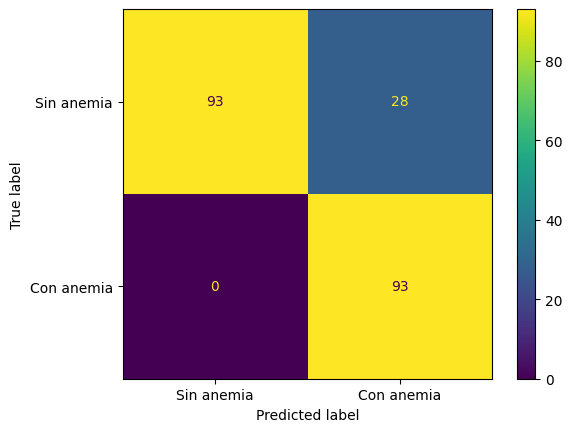

In [ ]:
confusion_matrix_tree = show_confusion_matrix(y_val, y_pred_tree)
plt.show()

El modelo clasificó correctamente:

* 93 casos de pacientes sin anemia.
* 93 casos de pacientes con anemia.

---

No se observaron falsos negativos (FN = 0), lo que indica que el modelo no omitió ningún caso positivo de anemia dentro del conjunto de validación. Esto coincide con el valor de recall = 1.00, indicando una capacidad perfecta para detectar la clase positiva.

Sin embargo, se identificaron **28** falsos positivos, donde pacientes sin anemia fueron clasificados como casos positivos. Este comportamiento explica la reducción en la métrica de precisión (precision = 0.77), ya que una proporción de las predicciones positivas realizadas por el modelo fueron incorrectas.

En el contexto del problema, el modelo prioriza la detección de casos de anemia sobre evitar falsas alarmas. Esto puede ser favorable si el objetivo principal es minimizar casos no detectados, aunque implica realizar evaluaciones adicionales sobre pacientes que podrían no presentar anemia.

### 2.3 Validación cruzada

In [ ]:
pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=82, max_depth=2, min_samples_leaf=3, min_samples_split=5))
])

In [ ]:
scores_tree = cross_validate(
    pipeline_tree,
    X_temp,
    y_temp,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ],
    return_train_score=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [ ]:
results_tree = pd.DataFrame(scores_tree)
results_tree

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,0.038309,0.021435,0.880165,0.785185,1.000000,0.879668
1,0.058072,0.062930,0.917355,0.841270,1.000000,0.913793
2,0.019274,0.030427,0.892116,0.801527,1.000000,0.889831
3,0.036970,0.066431,0.887967,0.819672,0.952381,0.881057
4,0.043490,0.025427,0.887967,0.795455,1.000000,0.886076


In [ ]:
metrics_cv_tree = show_cv_metrics(scores_tree)
metrics_cv_tree

{'accuracy': '0.8931 ± 0.0127',
 'precision': '0.8086 ± 0.0198',
 'recall': '0.9905 ± 0.019',
 'f1': '0.8901 ± 0.0124'}


| Métrica   | Media ± Desviación estándar |
| --------- | --------------------------: |
| Accuracy  |         **0.8931 ± 0.0127** |
| Precision |         **0.8086 ± 0.0198** |
| Recall    |         **0.9905 ± 0.0190** |
| F1-Score  |         **0.8901 ± 0.0124** |

---

#### Análisis

Los resultados obtenidos mediante validación cruzada indican que el modelo mantiene un desempeño consistente sobre las distintas particiones del conjunto de entrenamiento.

El aspecto más destacado del modelo es su elevada capacidad para detectar casos positivos.

El `recall` promedio de `0.9905 ± 0.0190` muestra que el árbol de decisión identifica correctamente prácticamente todos los pacientes con anemia en las diferentes iteraciones de la validación cruzada. La baja desviación estándar observada indica que este comportamiento se mantiene de forma consistente entre los distintos folds.

La `precision` promedio de `0.8086 ± 0.0198` evidencia que el modelo genera algunos falsos positivos; sin embargo, esta métrica presenta una variabilidad reducida, lo que sugiere que dicho comportamiento es estable y reproducible sobre diferentes particiones del conjunto de entrenamiento.

Asimismo, el `accuracy` `(0.8931 ± 0.0127)` y el `F1-score` `(0.8901 ± 0.0124)` muestran una variación mínima entre iteraciones, aportando evidencia de que el modelo presenta un rendimiento consistente y una adecuada capacidad de generalización.

En conjunto, la validación cruzada indica que el árbol de decisión ofrece un comportamiento estable y prioriza la detección de la clase positiva, manteniendo un rendimiento consistente sobre diferentes subconjuntos de datos.

### 2.4 Optimización de hiperparametros

In [ ]:
param_grid_tree = {
    # Profundidad máxima del árbol
    "max_depth": randint(2, 20),

    # Cantidad mínima de muestras para dividir un nodo
    "min_samples_split": randint(2, 20),

    # Cantidad mínima de muestras en una hoja
    "min_samples_leaf": randint(1, 20),

    # Cantidad máxima de features consideradas por split
    "max_features": ["sqrt", "log2", None],

    # Criterio de división
    "criterion": ["gini", "entropy", "log_loss"],

    # Balanceo de clases
    "class_weight": [None, "balanced"],

    # Control de complejidad mediante poda
    "ccp_alpha": uniform(0.0, 0.05)
}

In [ ]:
random_search_tree = RandomizedSearchCV(
  estimator = tree_model,
  param_distributions = param_grid_tree,
  n_iter = 100,
  cv = 5,
  scoring = 'recall',
  n_jobs = -1,
  verbose = 1,
  random_state = 82
)

In [ ]:
random_search_tree.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=DecisionTreeClassifier(max_depth=2,
                                                    min_samples_leaf=3,
                                                    min_samples_split=5,
                                                    random_state=82),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'ccp_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7dfdbbd2d1f0>,
                                        'class_weight': [None, 'balanced'],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dfdbbd2eed0>,
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dfdbbd2f3b0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dfdcffcc440>},
                   random_state=82, scoring='recall', verbose=1)

In [ ]:
# Mejores parametros
random_search_tree.best_params_

{'ccp_alpha': np.float64(0.013761283490066884),
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 4,
 'max_features': None,
 'min_samples_leaf': 17,
 'min_samples_split': 16}

In [ ]:
# Mejor recall obtenido
random_search_tree.best_score_

np.float64(1.0)

In [ ]:
# Guardamos el mejor estimador
best_tree = random_search_tree.best_estimator_

In [ ]:
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.013761283490066884),
                       class_weight='balanced', criterion='entropy',
                       max_depth=4, min_samples_leaf=17, min_samples_split=16,
                       random_state=82)

In [ ]:
y_pred_tree = best_tree.predict(X_val)

In [ ]:
print(show_metrics('best tree estimator', y_val, y_pred_tree))

best tree estimator metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0}


#### Validación cruzada, mejor estimador

In [ ]:
pipeline_best_tree = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', random_search_tree.best_estimator_)
    ]
)

scores_best_tree = cross_validate(
    pipeline_best_tree,
    X_temp,
    y_temp,
    cv=5,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ],
    return_train_score=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [ ]:
scores_best_tree

{'fit_time': array([0.05470681, 0.05022764, 0.06992197, 0.02299786, 0.04045963]),
 'score_time': array([0.04586363, 0.07308578, 0.04151964, 0.06992769, 0.04208446]),
 'test_accuracy': array([1., 1., 1., 1., 1.]),
 'test_precision': array([1., 1., 1., 1., 1.]),
 'test_recall': array([1., 1., 1., 1., 1.]),
 'test_f1': array([1., 1., 1., 1., 1.])}

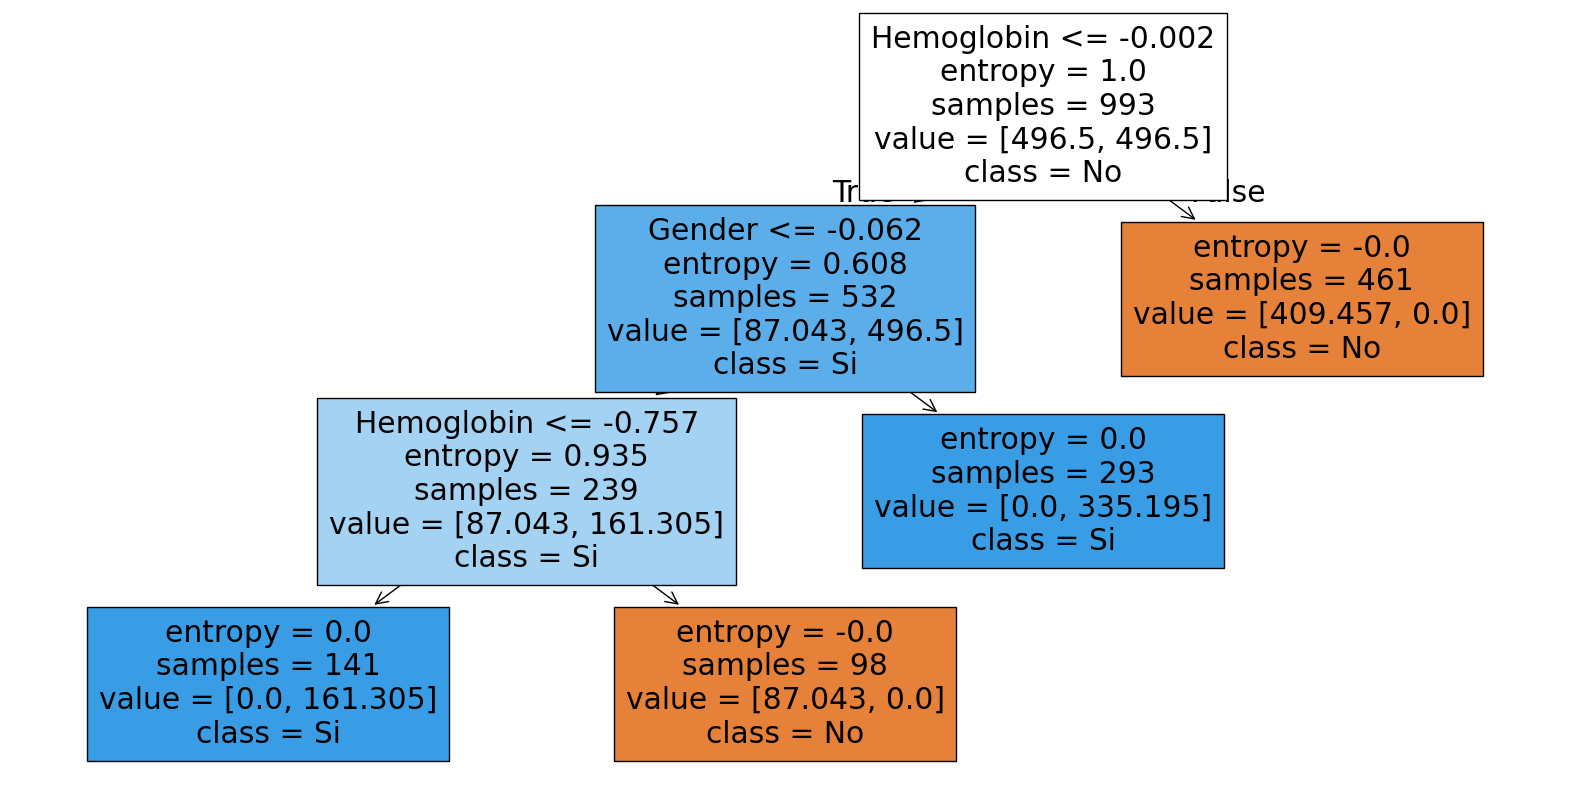

In [ ]:
# creamos un grafo del mejor estimador
plt.figure(figsize=(20,10))

plot_tree(
    best_tree,
    feature_names=X_temp.columns,
    class_names=["No", "Si"],
    filled=True
)

plt.show()

### 2.5 Observaciones

Luego de realizar la optimización de hiperparametros, se obtuvo un modelo que presento metricas perfectas (`accuracy`, `recall`, `precision` y `f1-score` iguales a 1.0) sobre el conjunto de validación. Si bien, este resultado podría indicar un excelente desempeño, también representa una señal que requiere una investigación más exhaustiva para descartar posibles problemas de sobreajuste.

Dado que el modelo de árbol que se presento inicialmente ya presentaba un desempeño satisfactorio, se decidio conservar el mismo como posible modelo final.

## 3. RandomForest

In [ ]:
rf_model = RandomForestClassifier(
    max_depth = 2,
    n_estimators = 100,
    min_samples_leaf = 3,
    min_samples_split = 5,
    random_state = 82
)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, min_samples_leaf=3, min_samples_split=5,
                       random_state=82)

In [ ]:
y_pred_rf = rf_model.predict(X_val)

### 3.1 Evaluación de métricas

In [ ]:
metrics_rf = show_metrics('random forest', y_val, y_pred_rf)
metrics_rf

"random forest metrics: {'accuracy': 0.93, 'precision': 0.86, 'recall': 1.0, 'f1-score': 0.93}"

La evaluación del modelo `RandomForest` realizada sobre el conjunto de validación presento las siguientes métricas:


| Métrica   | Valor   | Interpretación       |
|---------- |------   |--------------|
| Accuracy  | 0.93    | El modelo clasifico correctamente el 93% de las muestras.       |
| Precision | 0.86    | De todas las predicciones positivas, el 86% corresponden realmente a casos positivos. |
| Recall    | 1.00    | El modelo clasifico correctamente el 100% de casos positivos del conjunto de datos.       |
| F1-Score  | 0.93    | El balance entre precisión y recall fue de un 93%, indicando un buen desempeño general considerando ambas métricas.       |

---

#### **Análisis**

El modelo **Random Forest** obtuvo un `recall` de 1.00, lo que indica que fue capaz de identificar correctamente todos los casos positivos dentro del conjunto de validación. Desde el punto de vista clínico, este comportamiento es especialmente favorable, ya que minimiza el riesgo de no detectar pacientes con anemia (falsos negativos).

La métrica `precision`, con un valor del 86%, indica que la mayoría de las predicciones positivas corresponden efectivamente a pacientes con anemia. Sin embargo, el modelo genera algunos falsos positivos, clasificando como positivos ciertos pacientes que en realidad no presentan anemia. Este comportamiento es esperable, puesto que el modelo esta orientado a maximizar el recall.

El `accuracy` del 93% refleja un buen desempeño global, indicando que la mayoría de las observaciones fueron clasificadas correctamente.

El `F1-Score` de 0.93 evidencia un buen equilibrio entre `precision` y `recall`. Aunque el modelo prioriza la sensibilidad, mantiene una `precision` relativamente alta, lo que sugiere una capacidad adecuada para identificar casos positivos sin incrementar la cantidad de falsas alarmas.

### 3.2 Matriz de confusión

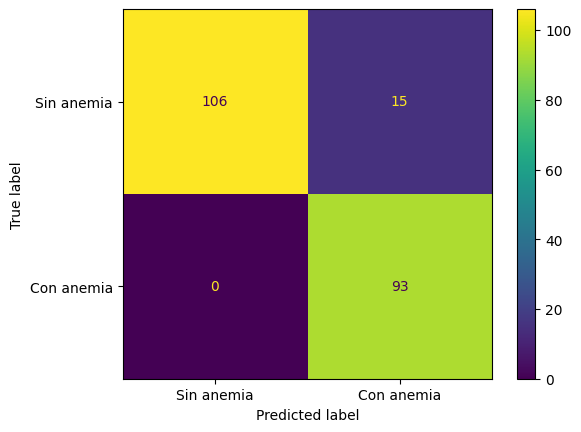

In [ ]:
confusion_matrix_rf = show_confusion_matrix(y_val, y_pred_rf)
plt.show()

El modelo clasifico correctamente:

* 93 pacientes con anemia.
* 106 pacientes sin anemia.

---

El modelo no registro falsos negativos (`FN = 0`), indicando que el modelo fue capaz de identificar correctamente todos los pacientes con anemia. Este resultado coincide con el recall obtenido al analizar las métricas obtenidas (`recall = 1.00`).

En contraparte, se observaron 15 falsos positivos (pacientes que el modelo clasifico como anemicos cuando no tenian la enfermedad). Aunque estas predicciones puedan reducir la precision del modelo, su cantidad es relativamente baja y resulta consistente con la precision del 86% obtenida en el análisis anterior.

### 3.3 Validación cruzada

In [ ]:
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('rf model', RandomForestClassifier(
    max_depth = 2,
    n_estimators = 100,
    min_samples_leaf = 3,
    min_samples_split = 5,
    random_state = 82
    ))
])

In [ ]:
scores_rf = cross_validate(
    pipeline_rf,
    X_temp,
    y_temp,
    cv = 5,
    scoring = [
        'accuracy',
        'recall',
        'precision',
        'f1'
    ],
    return_train_score=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [ ]:
results_rf = pd.DataFrame(scores_rf)
results_rf

,fit_time,score_time,test_accuracy,test_recall,test_precision,test_f1
0,0.383043,0.048106,0.933884,0.971698,0.887931,0.927928
1,0.352219,0.038060,0.904959,0.915094,0.873874,0.894009
2,0.459984,0.037410,0.937759,0.990476,0.881356,0.932735
3,0.330959,0.059663,0.883817,0.895238,0.846847,0.870370
4,0.671797,0.032212,0.970954,1.000000,0.937500,0.967742


In [ ]:
metrics_cv_rf = show_cv_metrics(results_rf)
metrics_cv_rf

{'accuracy': '0.9263 ± 0.0333',
 'precision': '0.8855 ± 0.033',
 'recall': '0.9545 ± 0.0467',
 'f1': '0.9186 ± 0.0375'}

| Métrica   | Media ± Desviación estándar |
| --------- | --------------------------: |
| Accuracy  |         **0.9263 ± 0.0333** |
| Precision |         **0.8855 ± 0.0330** |
| Recall    |         **0.9545 ± 0.0467** |
| F1-Score  |         **0.9186 ± 0.0375** |


---

#### Análisis

Los resultados obtenidos mediante validación cruzada muestran que el modelo mantiene un desempeño elevado sobre las distintas particiones del conjunto de entrenamiento.

El principal aspecto a destacar es el equilibrio alcanzado entre las métricas de evaluación.

El modelo obtiene un `recall` promedio de `0.9545 ± 0.0467`, lo que indica una alta capacidad para detectar correctamente los casos positivos, mientras que la `precision` promedio de `0.8855 ± 0.0330` refleja que la mayoría de las predicciones positivas corresponden efectivamente a pacientes con anemia.

El `accuracy` `(0.9263 ± 0.0333)` y el `F1-score` `(0.9186 ± 0.0375)` evidencian un rendimiento sólido y balanceado, mostrando que el modelo mantiene un buen compromiso entre la detección de la clase positiva y la fiabilidad de sus predicciones.

En conjunto, la validación cruzada proporciona evidencia de que el modelo posee una buena capacidad de generalización y un rendimiento consistente, manteniendo un equilibrio adecuado entre las principales métricas de clasificación.

### 3.4 Optimización de hiperparametros

In [ ]:
param_grid_rf = {
    # cantidd de árboles
    "n_estimators": randint(100, 1000),

    # profundidad máxima de los árboles
    "max_depth": [None] + list(range(2, 22, 5)),

    # mínimo de muestras para dividir un nodo
    "min_samples_split": randint(2, 20),

    # mínimo de muestras por hoja
    "min_samples_leaf": randint(1, 11),

    # número máximo de variables consideradas en cada división
    "max_features": ["sqrt", "log2", None],

    # criterio de división
    "criterion": ["gini", "entropy", "log_loss"],

    # muestreo con reemplazo
    "bootstrap": [True, False],

    # balanceo de clases
    "class_weight": [None, "balanced", "balanced_subsample"],

    # poda de los árboles
    "ccp_alpha": uniform(0.0, 0.02)
}

In [ ]:
random_search_rf = RandomizedSearchCV(
    estimator = rf_model,
    param_distributions = param_grid_rf,
    n_iter = 100,
    cv = 5,
    scoring = 'recall',
    n_jobs = -1,
    verbose = 1,
    random_state = 82
)

In [ ]:
random_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(max_depth=2,
                                                    min_samples_leaf=3,
                                                    min_samples_split=5,
                                                    random_state=82),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'ccp_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7dfdbbc93e30>,
                                        'class_weight': [None, 'balanced',
                                                         'balanced_subsample'],
                                        'criterion': [...
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dfdbbc5ddc0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dfdbab10830>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dfdbbc77b00>},
                   random_state=82, scoring='recall', verbose=1)

In [ ]:
random_search_rf.best_params_

{'bootstrap': False,
 'ccp_alpha': np.float64(0.0017602751611517009),
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 7,
 'max_features': None,
 'min_samples_leaf': 1,
 'min_samples_split': 16,
 'n_estimators': 398}

In [ ]:
random_search_rf.best_score_

np.float64(1.0)

In [ ]:
best_rf = random_search_rf.best_estimator_

In [ ]:
best_rf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=False,
                       ccp_alpha=np.float64(0.0017602751611517009),
                       class_weight='balanced', criterion='entropy',
                       max_depth=7, max_features=None, min_samples_split=16,
                       n_estimators=398, random_state=82)

In [ ]:
y_pred_best_rf = best_rf.predict(X_val)

In [ ]:
print(show_metrics('best rf',y_val, y_pred_best_rf))

best rf metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0}


#### Validación cruzada, mejor estimador

In [ ]:
pipeline_best_rf = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', random_search_rf.best_estimator_)
    ]
)

In [ ]:
scores_best_rf = cross_validate(
    pipeline_best_rf,
    X_temp,
    y_temp,
    cv = 5,
    scoring = [
        'recall',
        'accuracy',
        'f1',
        'precision'
    ],
    return_train_score = False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [ ]:
scores_best_rf

{'fit_time': array([0.88065839, 0.85914373, 0.85275698, 0.84912181, 1.14571619]),
 'score_time': array([0.04667735, 0.04478216, 0.04503775, 0.04546142, 0.05996656]),
 'test_recall': array([1., 1., 1., 1., 1.]),
 'test_accuracy': array([1., 1., 1., 1., 1.]),
 'test_f1': array([1., 1., 1., 1., 1.]),
 'test_precision': array([1., 1., 1., 1., 1.])}

### 3.5 Observaciones

Al realizar la optimización de hiperparametros, el mejor estimador presento métricas perfectas al realizar el analisis sobre el conjunto de validación (`accuracy`, `recall`, `precision` y `f1` iguales a 1.0).

Aunque el resultado puede indicar un rendimiento excelente, tambien es un resultado que requiere de investigación, para descartar posibles problemas de sobreajuste.

Puesto que el primer modelo `Random Forest` ya presento un desempeño muy bueno, y teniendo en cuenta la investigación que se debe realizar, se opto por conservar el modelo presentado inicialmente.

## 4. XGBoost

In [ ]:
xgb_model = XGBClassifier(
    objective = 'binary:logistic',
    eval_metric = 'logloss',
    n_estimators = 100,
    learning_rate = 0.01,
    max_depth = 2,
    random_state = 82
)

In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

###4.1 Evaluación de metricas

In [ ]:
y_pred_xgb = xgb_model.predict(X_val)

In [ ]:
metrics_xgb = show_metrics('xgb', y_val, y_pred_xgb)
metrics_xgb

"xgb metrics: {'accuracy': 0.93, 'precision': 0.87, 'recall': 1.0, 'f1-score': 0.93}"

La evaluación del modelo `XGBClassifier` realizada sobre el conjunto de validación presento las siguientes métricas:


| Métrica   | Valor   | Interpretación       |
|---------- |------   |--------------|
| Accuracy  | 0.93    | El modelo clasifico correctamente el 93% de las muestras.       |
| Precision | 0.87    | De todas las predicciones positivas, el 87% corresponden realmente a casos positivos. |
| Recall    | 1.00    | El modelo clasifico correctamente el 100% de casos positivos del conjunto de datos.       |
| F1-Score  | 0.93    | El balance entre precisión y recall fue de un 93%, indicando un buen desempeño general considerando ambas métricas.       |

---

#### **Análisis**

El modelo `XGBoost Classifier` obtuvo un `recall` de 1.00, lo que indica que fue capaz de identificar correctamente todos los casos positivos del conjunto de validación. Esto es bueno para nuestro problema, puesto que indica que ningun paciente con anemia fue clasificado incorrectamente.

La `precision` del 87% indica que la mayoria de las predicciones positivas realizadas por el modelo corresponden a pacientes con anemia. Sin embargo, una pequeña proporcion de pacientes fueron clasificados como pacientes con anemia cuando no padecian la enfermedad.

El `accuracy` del 93% refleja un buen desempeño global, mientras que el `F1-Score`, tambien del 93%, evidencia un buen equilibrio del modelo entre la capacidad del modelo para detectar la clase positiva y la precision de sus predicciones.

Estos resultados muestran que el modelo presenta una elevada capacidad discriminatoria sobre el conjunto de validación, priorizando la detección de la clase positiva sin afectar significativamente el rendimiento general.

###4.2 Matriz de confusión

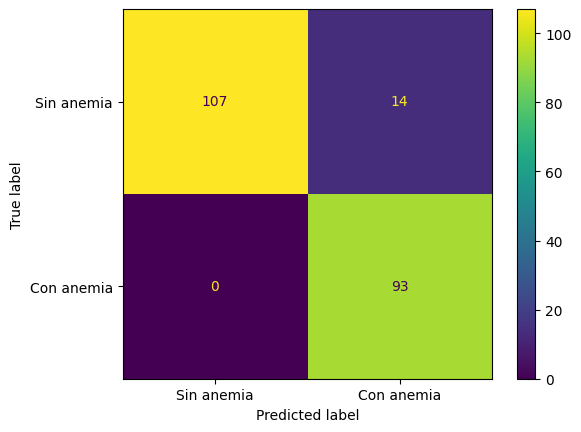

In [ ]:
confusion_matrix_xgb = show_confusion_matrix(y_val, y_pred_xgb)
plt.show()

El modelo fue capaz de detectar correctamente:

* 107 pacientes sin anemia.
* 93 pacientes con anemia.

---
El modelo clasificó correctamente 107 pacientes sin anemia y 93 pacientes con anemia, demostrando una elevada capacidad para diferenciar ambas clases.

No se registraron falsos negativos `(FN = 0)`, lo que indica que todos los pacientes con anemia fueron identificados correctamente. Este resultado es consistente con el recall de 1.00, confirmando que el modelo no omitió ningún caso positivo durante la evaluación.

Asimismo, se observaron 14 falsos positivos, correspondientes a pacientes sin anemia clasificados erróneamente como positivos. Aunque estas predicciones afectan la precisión del modelo, su cantidad es reducida y coherente con la precisión del 87% obtenida durante la evaluación de métricas.

En conjunto, la matriz de confusión evidencia que el modelo prioriza la detección de todos los casos de anemia, manteniendo al mismo tiempo un número reducido de falsas alarmas. Este comportamiento resulta adecuado para el objetivo del proyecto, donde minimizar los falsos negativos es más importante que reducir al máximo los falsos positivos.

###4.3 Validación cruzada

In [ ]:
pipeline_xgb = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            objective = 'binary:logistic',
            eval_metric = 'logloss',
            n_estimators = 100,
            learning_rate = 0.01,
            max_depth = 2,
            random_state = 82
        ))
    ]
)

In [ ]:
scores_xgb = cross_validate(
    pipeline_xgb,
    X_temp,
    y_temp,
    cv = 5,
    scoring = [
        'accuracy',
        'recall',
        'precision',
        'f1'
    ],
    return_train_score = False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [ ]:
results_xgb = pd.DataFrame(scores_xgb)
results_xgb

,fit_time,score_time,test_accuracy,test_recall,test_precision,test_f1
0,0.476415,0.036223,0.946281,1.000000,0.890756,0.942222
1,0.073548,0.026190,0.938017,1.000000,0.876033,0.933921
2,0.066731,0.062970,0.937759,1.000000,0.875000,0.933333
3,0.194935,0.024666,0.908714,0.961905,0.848739,0.901786
4,0.174324,0.023996,0.995851,1.000000,0.990566,0.995261


In [ ]:
metrics_cv_xgb = show_cv_metrics(results_xgb)

In [ ]:
metrics_cv_xgb

{'accuracy': '0.9453 ± 0.0316',
 'precision': '0.8962 ± 0.0549',
 'recall': '0.9924 ± 0.017',
 'f1': '0.9413 ± 0.0339'}

| Métrica   | Media ± Desviación estándar |
| --------- | --------------------------: |
| Accuracy  |         **0.9453 ± 0.0316** |
| Precision |         **0.8962 ± 0.0549** |
| Recall    |         **0.9924 ± 0.0170** |
| F1-Score  |         **0.9413 ± 0.0339** |


---

#### Análisis

Los resultados obtenidos mediante validación cruzada muestran que el modelo mantiene un desempeño elevado y consistente sobre las distintas particiones del conjunto de datos.

El aspecto más destacado del modelo es su excelente capacidad para detectar la clase positiva de forma consistente.

El `recall` promedio de `0.9924 ± 0.0170` indica que el modelo identifica correctamente prácticamente todos los casos positivos en las diferentes iteraciones, mientras que su reducida desviación estándar evidencia que este comportamiento permanece estable frente a distintas divisiones de los datos.

La `precision` promedio de `0.8962 ± 0.0549` muestra que la mayoría de las predicciones positivas corresponden efectivamente a pacientes con anemia. Aunque esta métrica presenta una variabilidad ligeramente superior a la observada en las demás, el rendimiento continúa siendo elevado en todas las particiones evaluadas.

El `accuracy` `(0.9453 ± 0.0316)` y el `F1-score` `(0.9413 ± 0.0339)` reflejan un desempeño sólido y equilibrado, indicando que el modelo mantiene un alto nivel de rendimiento de forma consistente durante el proceso de validación cruzada.

En conjunto, los resultados obtenidos proporcionan evidencia de que el modelo posee una buena capacidad de generalización y un comportamiento robusto, manteniendo un elevado nivel de desempeño sobre diferentes subconjuntos del conjunto de entrenamiento.

###4.4 Optimización de hiperparametros

In [ ]:
param_grid_xgb = {
    "n_estimators": [100, 200, 300, 500],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "max_depth": [3, 4, 5, 6, 8, 10],

    "min_child_weight": [1, 3, 5, 7],

    "subsample": [0.6, 0.8, 1.0],

    "colsample_bytree": [0.6, 0.8, 1.0],

    "gamma": [0, 0.1, 0.3, 0.5, 1],

    "reg_alpha": [0, 0.1, 0.5, 1],

    "reg_lambda": [0.5, 1, 2, 5]
}

In [ ]:
random_search_xgb = RandomizedSearchCV(
    estimator = xgb_model,
    param_distributions = param_grid_xgb,
    cv = 5,
    n_iter = 100,
    n_jobs = -1,
    verbose = 1,
    scoring = 'recall',
    random_state = 82
)

In [ ]:
random_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           num_parallel_tree=None, ...),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5, 1],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [100, 200, 300, 500],
                                        'reg_alpha': [0, 0.1, 0.5, 1],
                                        'reg_lambda': [0.5, 1, 2, 5],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=82, scoring='recall', verbose=1)

In [ ]:
random_search_xgb.best_params_

{'subsample': 0.8,
 'reg_lambda': 5,
 'reg_alpha': 0.5,
 'n_estimators': 300,
 'min_child_weight': 7,
 'max_depth': 10,
 'learning_rate': 0.01,
 'gamma': 0,
 'colsample_bytree': 0.6}

In [ ]:
random_search_xgb.best_score_

np.float64(1.0)

In [ ]:
best_xgb = random_search_xgb.best_estimator_

In [ ]:
best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_best_xgb = best_xgb.predict(X_val)

In [ ]:
print(show_metrics('best xgb', y_val, y_pred_best_xgb))

best xgb metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0}


#### Validación cruzada, mejor estimador

In [ ]:
pipeline_best_xgb = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', random_search_xgb.best_estimator_)
    ]
)

In [ ]:
scores_best_xgb = cross_validate(
    pipeline_best_xgb,
    X_temp,
    y_temp,
    cv = 5,
    scoring = [
        'accuracy',
        'precision',
        'recall',
        'f1'
    ],
    return_train_score = False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [ ]:
results_best_xgb = pd.DataFrame(scores_best_xgb)
results_best_xgb

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,0.504287,0.059920,0.991736,0.981481,1.0,0.990654
1,0.766779,0.022973,1.000000,1.000000,1.0,1.000000
2,0.292971,0.053944,1.000000,1.000000,1.0,1.000000
3,0.323797,0.042085,1.000000,1.000000,1.0,1.000000
4,0.255129,0.018894,1.000000,1.000000,1.0,1.000000


###4.5 Observaciones

Se realizó un proceso de optimización de hiperparámetros con el objetivo de mejorar el desempeño del modelo `XGBoost Classifier` mediante la evaluación de distintas combinaciones de parámetros.

Como resultado de este proceso, el mejor estimador obtuvo un rendimiento perfecto tanto durante la validación cruzada como sobre el conjunto de validación, alcanzando valores de `1.00` en las métricas de `accuracy`, `precision`, `recall` y `F1-score`.

Si bien estos resultados representan un excelente desempeño, un rendimiento perfecto en todas las métricas puede indicar que el modelo se encuentra excesivamente ajustado a los datos utilizados durante el entrenamiento y la validación. Aunque este comportamiento no constituye por sí mismo una evidencia de sobreajuste, sí justifica realizar una evaluación cuidadosa de la capacidad de generalización del modelo antes de adoptarlo como solución final.

Considerando que el modelo XGBoost entrenado con la configuración inicial ya presentaba un desempeño elevado y consistente, respaldado por la evaluación sobre el conjunto de validación y por la validación cruzada, se decidió mantener dicho modelo como candidato final. Esta decisión prioriza la utilización de un modelo con un comportamiento estable y una capacidad de generalización respaldada por las evaluaciones realizadas, en lugar de seleccionar un modelo cuyo rendimiento perfecto requiere una validación adicional para confirmar que no se encuentra sobreajustado a los datos disponibles.

## 5. LightGBM

In [ ]:
lgbm_model = LGBMClassifier(
    objective = 'binary',
    n_estimators = 100,
    learning_rate = 0.01,
    max_depth = 2,
    num_leaves = 15,
    n_jobs = -1,
    verbosity = -1,
    random_state = 82
)

In [ ]:
lgbm_model.fit(X_train, y_train)

LGBMClassifier(learning_rate=0.01, max_depth=2, n_jobs=-1, num_leaves=15,
               objective='binary', random_state=82, verbosity=-1)

### 5.1 Análisis de métricas

In [ ]:
y_pred_lgbm = lgbm_model.predict(X_val)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
metrics_lgbm = show_metrics('lgbm', y_val, y_pred_lgbm)
metrics_lgbm

"lgbm metrics: {'accuracy': 0.93, 'precision': 0.87, 'recall': 1.0, 'f1-score': 0.93}"

| Métrica   | Valor   | Interpretación       |
|---------- |------   |--------------|
| Accuracy  | 0.93    | El modelo clasifico correctamente el 93% de las muestras.       |
| Precision | 0.87    | De todas las predicciones positivas, el 87% corresponden realmente a casos positivos. |
| Recall    | 1.00    | El modelo clasifico correctamente el 100% de casos positivos del conjunto de datos.       |
| F1-Score  | 0.93    | El balance entre precisión y recall fue de un 93%, indicando un buen desempeño general considerando ambas métricas.       |

---

#### **Análisis**

Los resultados obtenidos muestran que el modelo `LightGBM Classifier` presenta un desempeño sólido sobre el conjunto de validación, obteniendo valores elevados en todas las métricas evaluadas.

El aspecto más destacado del modelo es su capacidad para identificar correctamente todos los casos positivos, reflejada en un `recall` de `1.00`. Este resultado indica que ningún paciente con anemia fue clasificado erróneamente como un caso negativo durante la evaluación, lo cual resulta especialmente favorable considerando el objetivo del proyecto.

La `precision` del `87%` muestra que la mayoría de las predicciones positivas realizadas por el modelo corresponden efectivamente a pacientes con anemia. No obstante, existe una pequeña proporción de falsos positivos, lo que indica que algunos pacientes sin anemia fueron clasificados incorrectamente como positivos.

Por su parte, el `accuracy` del `93%` y el `F1-score` de `0.93` reflejan un desempeño equilibrado, evidenciando que el modelo mantiene una alta capacidad de detección de la clase positiva sin comprometer significativamente la precisión de sus predicciones.

En conjunto, estos resultados indican que el modelo presenta una buena capacidad para discriminar entre pacientes con y sin anemia sobre el conjunto de validación, manteniendo un equilibrio adecuado entre sensibilidad y precisión.

### 5.2 Matriz de confusión

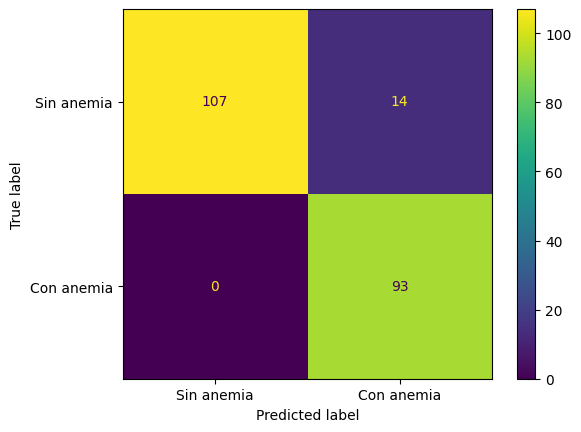

In [ ]:
confusion_matrix_lgbm = show_confusion_matrix(y_val, y_pred_lgbm)
plt.show()

El modelo `LightGBM Classifier` clasifico correctamente:

* 107 pacientes sin anemia.
* 93 pacientes con anemia.

---

#### Análisis

El modelo logro clasificar correctamente 107 pacientes sin anemia y 93 pacientes con anemia, demostrando una buena capacidad discriminatoria para ambas clases.

La matriz de confusión muestra que no se encontraron `falsos negativos` (Pacientes que el modelo clasifico como 'sin anemia' cuando padecian la enfermedad). Esto corresponde con el `recall` obtenido `(1.00)`, demostrando que el modelo tiene una excelente capacidad discriminativa sobre la clase positiva.

Se observa la presencia de `14 falsos positivos` (Pacientes que el modelo clasifico como positivos, cuando en realidad eran negativos), que, si bien afecta la precisión del modelo al momento de predecir, es una cantidad pequeña y a la vez es consistente con el `87%` de la metrica `precision`.

En conclusión, la matriz de confusión del modelo `LightGBM Classifier` demuestra que el modelo prioriza la detección de casos positivos manteniendo un número bajo de falsos positivos. Esto es esencialmente bueno para nuestro problema, donde priorizamos minimizar al máximo los falsos negativos.

### 5.3 Validación cruzada

In [ ]:
pipeline_lgbm = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(
            objective = 'binary',
            n_estimators = 100,
            learning_rate = 0.01,
            max_depth = 2,
            num_leaves = 15,
            n_jobs = -1,
            verbosity = -1,
            random_state = 82
            )
        )
    ]
)

In [ ]:
scores_lgbm = cross_validate(
    pipeline_lgbm,
    X_temp,
    y_temp,
    cv = 5,
    return_train_score = False,
    scoring = [
        'accuracy',
        'precision',
        'recall',
        'f1'
    ]
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/pytho

In [ ]:
results_lgbm = pd.DataFrame(scores_lgbm)

In [ ]:
metrics_cv_lgbm = show_cv_metrics(results_lgbm)
metrics_cv_lgbm

{'accuracy': '0.9453 ± 0.0316',
 'precision': '0.8962 ± 0.0549',
 'recall': '0.9924 ± 0.017',
 'f1': '0.9413 ± 0.0339'}

#### Análisis

El análisis de validación cruzada demostro que el modelo mantiene un comportamiento consistente entre las distintas particiones del conjunto de datos.

Lo mas destacado del análisis es la alta capacidad del modelo para detectar casos positivos.

El `recall` promedio de `0.9924 ± 0.017` indica que el modelo fue capaz de mantener una alta capacidad predictiva sobre la clase positiva con los distintos folds del conjunto de datos. La reducida desviación estándar demuestra que el modelo mantiene este comportamiento de forma consistente entre las distintas iteraciones de la validación cruzada.

La `precision` promedio de `0.8962 ± 0.0549` muestra que la mayoria de las predicciones realizadas entre las distintas iteraciones realmente pertenecian a pacientes con anemia. Si bien, esta métrica presenta una variabilidad ligeramente superior a las demas métricas, los resultados son consistentes entre todas las iteraciones realizadas.

Por su parte, el `accuracy` `(0.9453 ± 0.0316)` y el `F1-Score` `(0.9413 ± 0.0339)` reflejan un desempeño sólido y equilibrado. Las desviaciones estándar asociadas a ambas métricas indican que el modelo mantiene un comportamiento consistente frente a diferentes divisiones del conjunto de entrenamiento.

Los resultados de la validación cruzada evidencian que el modelo presenta una buena capacidad de generalización y un rendimiento estable, manteniendo un equilibrio adecuado entre la detección de casos positivos y la precisión de sus predicciones.

### 5.4 Optimización de hiperparametros

In [ ]:
param_grid_lgbm = {
    "n_estimators": [100, 200, 300, 500, 700, 1000],

    "learning_rate": [0.005, 0.01, 0.03, 0.05, 0.1],

    "num_leaves": [15, 31, 63, 127, 255],

    "max_depth": [-1, 3, 5, 7, 10, 15],

    "min_child_samples": [5, 10, 20, 30, 50, 100],

    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],

    "reg_alpha": [0, 0.01, 0.1, 0.5, 1, 5],

    "reg_lambda": [0, 0.01, 0.1, 0.5, 1, 5],
}

In [ ]:
random_search_lgbm = RandomizedSearchCV(
    estimator = lgbm_model,
    param_distributions = param_grid_lgbm,
    cv = 5,
    n_iter = 100,
    n_jobs = -1,
    verbose = 1,
    scoring = 'recall',
    random_state = 82
)

In [ ]:
random_search_lgbm.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(learning_rate=0.01, max_depth=2,
                                            n_jobs=-1, num_leaves=15,
                                            objective='binary', random_state=82,
                                            verbosity=-1),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.005, 0.01, 0.03,
                                                          0.05, 0.1],
                                        'max_depth': [-1, 3, 5, 7, 10, 15],
                                        'min_child_samples': [5, 10, 20, 30, 50,
                                                              100],
                                        'n_estimators': [100, 200, 300, 500,
                                                         700, 1000],
                                        'num_leaves': [15, 31, 63, 127, 255],
                                        'reg_alpha': [0, 0.01, 0.1, 0.5, 1, 5],
                                        'reg_lambda': [0, 0.01, 0.1, 0.5, 1, 5],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=82, scoring='recall', verbose=1)

In [ ]:
random_search_lgbm.best_score_

np.float64(1.0)

In [ ]:
random_search_lgbm.best_params_

{'subsample': 1.0,
 'reg_lambda': 1,
 'reg_alpha': 5,
 'num_leaves': 63,
 'n_estimators': 1000,
 'min_child_samples': 10,
 'max_depth': 10,
 'learning_rate': 0.03,
 'colsample_bytree': 0.6}

In [ ]:
best_lgbm = random_search_lgbm.best_estimator_

In [ ]:
best_lgbm.fit(X_train, y_train)

LGBMClassifier(colsample_bytree=0.6, learning_rate=0.03, max_depth=10,
               min_child_samples=10, n_estimators=1000, n_jobs=-1,
               num_leaves=63, objective='binary', random_state=82, reg_alpha=5,
               reg_lambda=1, verbosity=-1)

In [ ]:
y_pred_best_lgbm = best_lgbm.predict(X_val)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print(show_metrics('best lgbm', y_val, y_pred_best_lgbm))

best lgbm metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0}


#### Validación cruzada, mejor estimador

In [ ]:
pipeline_best_lgbm = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', random_search_lgbm.best_estimator_)
    ]
)

In [ ]:
scores_best_lgbm = cross_validate(
    pipeline_best_lgbm,
    X_temp,
    y_temp,
    cv = 5,
    scoring = [
        'accuracy',
        'precision',
        'recall',
        'f1'
    ],
    return_train_score = False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/pytho

In [ ]:
results_best_lgbm = pd.DataFrame(scores_best_lgbm)

In [ ]:
results_best_lgbm

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,0.165398,0.022691,1.0,1.0,1.0,1.0
1,0.126351,0.022246,1.0,1.0,1.0,1.0
2,0.107696,0.021041,1.0,1.0,1.0,1.0
3,0.139980,0.020912,1.0,1.0,1.0,1.0
4,0.107687,0.019796,1.0,1.0,1.0,1.0


In [ ]:
metrics_cv_best_lgbm = show_cv_metrics(results_best_lgbm)
metrics_cv_best_lgbm

{'accuracy': '1.0 ± 0.0',
 'precision': '1.0 ± 0.0',
 'recall': '1.0 ± 0.0',
 'f1': '1.0 ± 0.0'}

### 5.5 Observaciones

La optimización de hiperparámetros permitió obtener un modelo con un rendimiento perfecto en todas las métricas evaluadas durante la validación cruzada (`accuracy`, `precision`, `recall` y `F1-score` de 1.00 ± 0.00).

No obstante, debido a que este comportamiento requiere una investigación adicional para descartar un posible sobreajuste y confirmar su capacidad de generalización, se optó por no utilizar este modelo en las siguientes etapas del proyecto.

En consecuencia, se seleccionó el modelo `LightGBM` entrenado con la configuración inicial, el cual demostró un desempeño elevado, estable y consistente durante las distintas evaluaciones realizadas.

## 6. CatBoost

In [ ]:
catboost_model = CatBoostClassifier(
    objective = 'Logloss',
    eval_metric = 'Recall',
    iterations = 150,
    learning_rate = 0.01,
    depth = 2,
    verbose = 0,
    random_state = 82
)

In [ ]:
catboost_model.fit(X_train, y_train)

CatBoostClassifier(depth=2, eval_metric='Recall', iterations=150, learning_rate=0.01, objective='Logloss', random_state=82, verbose=0)

### 6.1 Análisis de métricas

In [ ]:
y_pred_catboost = catboost_model.predict(X_val)

In [ ]:
metrics_catboost = show_metrics('catboost', y_val, y_pred_catboost)
metrics_catboost

"catboost metrics: {'accuracy': 0.96, 'precision': 0.94, 'recall': 0.98, 'f1-score': 0.96}"

| Métrica   | Valor   | Interpretación       |
|---------- |------   |--------------|
| Accuracy  | 0.96    | El modelo clasifico correctamente el 96% de las muestras.       |
| Precision | 0.94    | De todas las predicciones positivas, el 94% corresponden realmente a casos positivos. |
| Recall    | 0.98    | El modelo clasifico correctamente el 98% de casos positivos del conjunto de datos.       |
| F1-Score  | 0.96    | El balance entre precisión y recall fue de un 96%, indicando un buen desempeño general considerando ambas métricas.       |

---

#### **Análisis**

Los resultados obtenidos muestran que el modelo `CatBoost Classifier` presenta un desempeño sobresaliente sobre el conjunto de validación, obteniendo valores elevados en todas las métricas evaluadas.

Uno de los aspectos más destacados del modelo es el equilibrio entre la capacidad de detección y la precisión de sus predicciones. El `recall` de `0.98` indica que el modelo fue capaz de identificar correctamente la gran mayoría de los casos positivos, minimizando la cantidad de pacientes con anemia clasificados incorrectamente como negativos.

Por su parte, la `precision` del `94%` muestra que la mayoría de las predicciones positivas realizadas por el modelo corresponden efectivamente a pacientes con anemia, lo que refleja una baja proporción de falsos positivos.

El `accuracy` de `96%` evidencia un excelente desempeño global sobre el conjunto de validación, mientras que el `F1-score` de `0.96` confirma que el modelo mantiene un balance sólido entre `precision` y `recall`, sin favorecer excesivamente una métrica en detrimento de la otra.

En conjunto, estos resultados indican que el modelo presenta una elevada capacidad para discriminar entre pacientes con y sin anemia, ofreciendo un rendimiento equilibrado y consistente que lo posiciona como un candidato sólido para las siguientes etapas de evaluación del proyecto.

### 6.2 Matriz de confusión

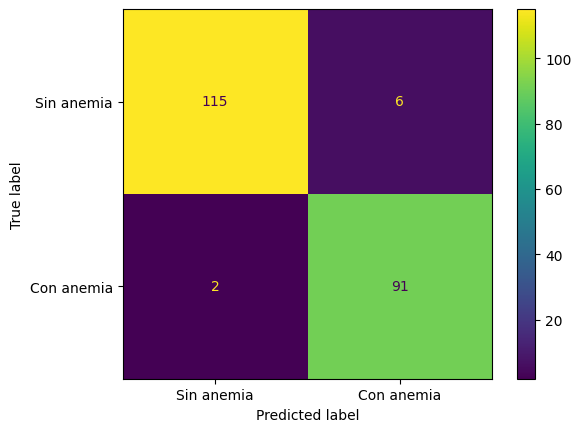

In [ ]:
confusion_matrix_catboost = show_confusion_matrix(y_val, y_pred_catboost)
plt.show()

El modelo logro clasificar correctamente:

* 91 pacientes con anemia.
* 115 pacientes sin anemia.

---

#### Análisis

La matriz de confusión evidencia que el modelo `CatBoost Classifier` presenta un excelente desempeño en la clasificación de ambas clases.

El modelo clasificó correctamente 206 de las 214 muestras del conjunto de validación, cometiendo únicamente 8 errores de clasificación, lo que es consistente con el `96%` de `accuracy` obtenido durante la evaluación.

Uno de los aspectos más relevantes es la baja cantidad de falsos negativos. El modelo solo dejó de identificar 2 pacientes con anemia, lo que demuestra una elevada capacidad para detectar la clase positiva y explica el `recall` del `98%` obtenido previamente.

Asimismo, el modelo produjo únicamente 6 falsos positivos, indicando que la mayoría de los pacientes clasificados como positivos realmente presentan anemia. Este comportamiento es consistente con la `precision` del `94%`, reflejando una baja tasa de falsas alarmas.

En conjunto, la distribución de errores observada en la matriz de confusión muestra que el modelo mantiene un buen equilibrio entre la detección de casos positivos y la correcta identificación de pacientes sin anemia, evidenciando un comportamiento sólido sobre el conjunto de validación.

### 6.3 Validación cruzada

In [ ]:
pipeline_catboost = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', CatBoostClassifier(
            objective = 'Logloss',
            eval_metric = 'Recall',
            iterations = 150,
            learning_rate = 0.01,
            depth = 2,
            verbose = 0,
            random_state = 82
            )
        )
    ]
)

In [ ]:
scores_catboost = cross_validate(
    pipeline_catboost,
    X_temp,
    y_temp,
    cv = 5,
    scoring = [
        'accuracy',
        'precision',
        'recall',
        'f1'
    ],
    return_train_score = False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [ ]:
results_catboost = pd.DataFrame(scores_catboost)

In [ ]:
metrics_cv_catboost = show_cv_metrics(results_catboost)
metrics_cv_catboost

{'accuracy': '0.9495 ± 0.0206',
 'precision': '0.9191 ± 0.0416',
 'recall': '0.9716 ± 0.0164',
 'f1': '0.9441 ± 0.0223'}

#### Análisis

La validación cruzada evidencia que el modelo `CatBoost Classifier` mantiene un rendimiento elevado y consistente sobre las distintas particiones del conjunto de entrenamiento, lo que proporciona evidencia de una buena capacidad de generalización.

Uno de los aspectos más destacados del modelo es el equilibrio entre la capacidad de detectar correctamente la clase positiva y la precisión de sus predicciones. El `recall` promedio de `0.9716 ± 0.0164` indica que el modelo identifica correctamente la gran mayoría de los casos positivos en las diferentes iteraciones de la validación cruzada. La baja desviación estándar observada sugiere que este comportamiento se mantiene de forma consistente entre los distintos folds.

La `precision` promedio de `0.9191 ± 0.0416` muestra que la mayoría de las predicciones positivas corresponden efectivamente a pacientes con anemia. Aunque esta métrica presenta una variabilidad ligeramente superior a la del resto, los valores obtenidos permanecen elevados en todas las particiones evaluadas.

Por su parte, el `accuracy` `(0.9495 ± 0.0206)` y el `F1-score` `(0.9441 ± 0.0223)` reflejan un desempeño sólido y equilibrado. Las desviaciones estándar relativamente bajas indican que el modelo mantiene un comportamiento estable frente a diferentes divisiones del conjunto de entrenamiento.

En conjunto, los resultados de la validación cruzada muestran que el modelo posee una buena capacidad de generalización y un rendimiento consistente, manteniendo un equilibrio adecuado entre la detección de casos positivos y la precisión de sus predicciones.

### 6.4 Optimización de hiperparametros

In [ ]:
param_grid_catboost = {

    "iterations": [100, 200, 300, 500, 700, 1000],

    "learning_rate": [0.005, 0.01, 0.03, 0.05, 0.1, 0.2],

    "depth": [2, 3, 4, 5, 6, 7, 8, 10],

    "l2_leaf_reg": [1, 3, 5, 7, 10, 15],

    "border_count": [32, 64, 128, 254],

    "bagging_temperature": [0, 0.5, 1, 3, 5],

    "random_strength": [0, 1, 2, 5, 10]
}

In [ ]:
random_search_cb = RandomizedSearchCV(
    estimator = catboost_model,
    param_distributions = param_grid_catboost,
    n_iter = 100,
    cv = 5,
    scoring = 'recall',
    n_jobs = -1,
    verbose = 1,
    random_state = 82
)

In [ ]:
random_search_cb.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=CatBoostClassifier(depth=2, eval_metric='Recall', iterations=150, learning_rate=0.01, objective='Logloss', random_state=82, verbose=0),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'bagging_temperature': [0, 0.5, 1, 3,
                                                                5],
                                        'border_count': [32, 64, 128, 254],
                                        'depth': [2, 3, 4, 5, 6, 7, 8, 10],
                                        'iterations': [100, 200, 300, 500, 700,
                                                       1000],
                                        'l2_leaf_reg': [1, 3, 5, 7, 10, 15],
                                        'learning_rate': [0.005, 0.01, 0.03,
                                                          0.05, 0.1, 0.2],
                                        'random_strength': [0, 1, 2, 5, 10]},
                   random_state=82, scoring='recall', verbose=1)

In [ ]:
random_search_cb.best_score_

np.float64(1.0)

In [ ]:
random_search_cb.best_params_

{'random_strength': 0,
 'learning_rate': 0.05,
 'l2_leaf_reg': 1,
 'iterations': 200,
 'depth': 2,
 'border_count': 64,
 'bagging_temperature': 1}

In [ ]:
best_catboost = random_search_cb.best_estimator_

In [ ]:
best_catboost.fit(X_train, y_train)

CatBoostClassifier(bagging_temperature=1, border_count=64, depth=2, eval_metric='Recall', iterations=200, l2_leaf_reg=1, learning_rate=0.05, objective='Logloss', random_state=82, random_strength=0, verbose=0)

In [ ]:
y_pred_best_cb = best_catboost.predict(X_val)

In [ ]:
print(show_metrics('best catboost', y_val, y_pred_best_cb))

best catboost metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0}


#### Validación cruzada, mejor estimador

In [ ]:
pipeline_best_cb = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', random_search_cb.best_estimator_)
    ]
)

In [ ]:
scores_best_cb = cross_validate(
    pipeline_best_cb,
    X_temp,
    y_temp,
    cv = 5,
    scoring = [
        'accuracy',
        'precision',
        'recall',
        'f1'
    ],
    return_train_score = False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [ ]:
results_best_cb = pd.DataFrame(scores_best_cb)

In [ ]:
metrics_cv_best_cb = show_cv_metrics(results_best_cb)
metrics_cv_best_cb

{'accuracy': '1.0 ± 0.0',
 'precision': '1.0 ± 0.0',
 'recall': '1.0 ± 0.0',
 'f1': '1.0 ± 0.0'}

### 6.5 Observaciones

El proceso de optimización de hiperparámetros produjo un estimador con un rendimiento perfecto (`accuracy`, `precision`, `recall` y `F1-score` de `1.00 ± 0.00`) durante la validación cruzada. Aunque estos resultados representan el mejor desempeño obtenido, requieren una investigación adicional para confirmar que el modelo mantiene dicho comportamiento sobre datos no vistos y descartar un posible sobreajuste. Dado que este análisis excede el alcance del presente proyecto, se decidió utilizar como modelo candidato el `CatBoost Classifier` entrenado con la configuración inicial, el cual presentó un desempeño elevado, estable y consistente durante todas las evaluaciones realizadas.

## 7. SVC

In [ ]:
svc_model = SVC(
    C = 0.1,
    kernel = "rbf",
    gamma = "scale",
    probability = True,
    class_weight = 'balanced',
    random_state = 82
)

In [ ]:
svc_model.fit(X_train, y_train)

SVC(C=0.1, class_weight='balanced', probability=True, random_state=82)

### 7.1 Análisis de métricas

In [ ]:
y_pred_svc = svc_model.predict(X_val)

In [ ]:
metrics_svc = show_metrics('svc', y_val, y_pred_svc)
metrics_svc

"svc metrics: {'accuracy': 0.9, 'precision': 0.81, 'recall': 0.99, 'f1-score': 0.89}"

| Métrica   | Valor   | Interpretación       |
|---------- |------   |--------------|
| Accuracy  | 0.90    | El modelo clasifico correctamente el 90% de las muestras.       |
| Precision | 0.81    | De todas las predicciones positivas, el 81% corresponden realmente a casos positivos. |
| Recall    | 0.99   | El modelo clasifico correctamente el 99% de casos positivos del conjunto de datos.       |
| F1-Score  | 0.89    | El balance entre precisión y recall fue de un 89%, indicando un buen desempeño general considerando ambas métricas.       |

---

#### **Análisis**


Los resultados obtenidos muestran que el modelo `Support Vector Classifier` (SVC) presenta un buen desempeño sobre el conjunto de validación, destacándose por su elevada capacidad para identificar correctamente los casos positivos.

El `recall` de `0.99` indica que el modelo fue capaz de detectar prácticamente todos los pacientes con anemia, dejando sin identificar únicamente una pequeña proporción de los casos positivos. Este comportamiento resulta especialmente favorable considerando que el objetivo principal del proyecto es maximizar la detección de pacientes con anemia.

La `precision` del `81%` muestra que la mayoría de las predicciones positivas realizadas por el modelo corresponden efectivamente a pacientes con anemia. No obstante, este valor también indica la presencia de una cantidad moderada de falsos positivos, es decir, algunos pacientes sin anemia fueron clasificados incorrectamente como positivos.

Por su parte, el `accuracy` del `90%` y el `F1-score` de `0.89` reflejan un desempeño general sólido y un equilibrio adecuado entre precisión y recall. Aunque el modelo prioriza la detección de la clase positiva, mantiene un nivel de rendimiento satisfactorio sobre el conjunto de validación.

En conjunto, los resultados evidencian que el modelo posee una elevada sensibilidad para detectar casos de anemia y un comportamiento consistente con el objetivo del proyecto, aceptando una mayor cantidad de falsos positivos como consecuencia de priorizar la identificación de la clase positiva.

### 7.2 Matriz de confusión

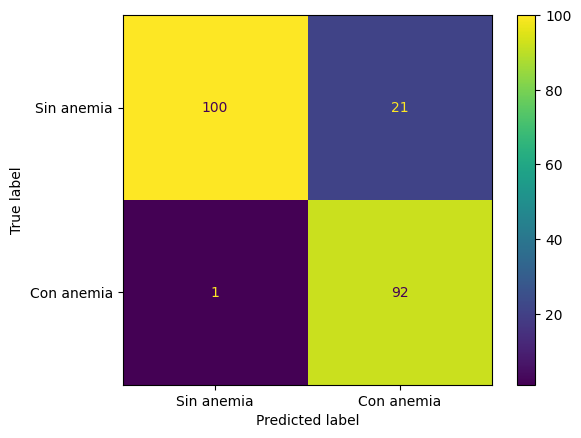

In [ ]:
confusion_matrix_svc = show_confusion_matrix(y_val, y_pred_svc)
plt.show()

El modelo clasifico correctamente:

* 100 casos de pacientes sin anemia.
* 92 casos de pacientes con anemia.

---

#### Análisis

La matriz de confusión muestra que el modelo `Support Vector Classifier` (SVC) presenta un buen desempeño en la identificación de pacientes con y sin anemia, clasificando correctamente 192 de las 214 muestras del conjunto de validación.

El aspecto más destacado del modelo es la baja cantidad de falsos negativos. Solo un paciente con anemia fue clasificado incorrectamente como un caso negativo, lo que explica el `recall` del `99%` obtenido durante la evaluación. Este comportamiento resulta especialmente favorable considerando que el objetivo del proyecto es maximizar la detección de pacientes con anemia.

Por otro lado, el modelo generó 21 falsos positivos, clasificando como positivos a algunos pacientes que realmente no presentaban anemia. Este comportamiento es consistente con la `precision` del `81%`, indicando que el modelo prioriza la detección de la clase positiva, aun cuando ello implique incrementar la cantidad de falsas alarmas.

En conjunto, la distribución de errores observada en la matriz de confusión evidencia que el modelo favorece la sensibilidad frente a la especificidad, manteniendo una elevada capacidad para detectar casos positivos a costa de aceptar una mayor cantidad de falsos positivos. Esta estrategia resulta coherente con el objetivo del proyecto, donde la omisión de un paciente con anemia representa un error potencialmente más relevante que la generación de una falsa alarma.

### 7.3 Validación cruzada

In [ ]:
pipeline_svc = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', SVC(
            C = 0.1,
            kernel = "rbf",
            gamma = "scale",
            probability = True,
            class_weight = 'balanced',
            random_state = 82
            )
        )
    ]
)

In [ ]:
scores_svc = cross_validate(
    pipeline_svc,
    X_temp,
    y_temp,
    cv = 5,
    scoring = [
        'accuracy',
        'precision',
        'recall',
        'f1'
    ],
    return_train_score = False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [ ]:
results_svc = pd.DataFrame(scores_svc)

In [ ]:
metrics_cv_svc = show_cv_metrics(results_svc)
metrics_cv_svc

{'accuracy': '0.9271 ± 0.0164',
 'precision': '0.8599 ± 0.0264',
 'recall': '0.9962 ± 0.0052',
 'f1': '0.9229 ± 0.0164'}

La validación cruzada muestra que el modelo `Support Vector Classifier` (SVC) mantiene un rendimiento elevado y consistente sobre las distintas particiones del conjunto de entrenamiento, proporcionando evidencia de una buena capacidad de generalización.

El aspecto más destacado del modelo es su excelente capacidad para detectar la clase positiva. El `recall` promedio de `0.9962 ± 0.0052` indica que el modelo identifica correctamente prácticamente todos los casos positivos durante las diferentes iteraciones de la validación cruzada. Además, la desviación estándar extremadamente baja evidencia que este comportamiento se mantiene de forma muy consistente entre los distintos folds.

La `precision` promedio de `0.8599 ± 0.0264` muestra que la mayoría de las predicciones positivas corresponden efectivamente a pacientes con anemia. Aunque esta métrica es inferior al recall, la baja variabilidad observada indica que el modelo mantiene un comportamiento estable respecto a la cantidad de falsos positivos generados.

Por su parte, el `accuracy` `(0.9271 ± 0.0164)` y el `F1-score` `(0.9229 ± 0.0164)` reflejan un desempeño sólido y equilibrado. Las reducidas desviaciones estándar asociadas a ambas métricas sugieren que el modelo presenta un comportamiento consistente frente a diferentes particiones del conjunto de entrenamiento.

En conjunto, los resultados de la validación cruzada indican que el modelo posee una buena capacidad de generalización y un rendimiento estable, destacándose por priorizar la detección de casos positivos sin presentar variaciones significativas entre las distintas iteraciones de la validación cruzada.

### 7.4 Optimización de hiperparametros

In [ ]:
param_grid_svc = {

    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],

    "kernel": ["rbf"],

    "gamma": ["scale", "auto", 0.0001, 0.001, 0.01, 0.1, 1],

    "degree": [2, 3, 4, 5],

    "coef0": [-1, -0.5, 0, 0.5, 1],

    "class_weight": [None, "balanced"],

    "tol": [1e-2, 1e-3, 1e-4],

    "shrinking": [True, False]
}

In [ ]:
random_search_svc = RandomizedSearchCV(
    estimator = svc_model,
    param_distributions = param_grid_svc,
    n_iter = 100,
    scoring = make_scorer(recall_score, pos_label=1),
    n_jobs = -1,
    verbose = 1,
    random_state = 82
)

In [ ]:
random_search_svc.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(estimator=SVC(C=0.1, class_weight='balanced',
                                 probability=True, random_state=82),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100,
                                              1000],
                                        'class_weight': [None, 'balanced'],
                                        'coef0': [-1, -0.5, 0, 0.5, 1],
                                        'degree': [2, 3, 4, 5],
                                        'gamma': ['scale', 'auto', 0.0001,
                                                  0.001, 0.01, 0.1, 1],
                                        'kernel': ['rbf'],
                                        'shrinking': [True, False],
                                        'tol': [0.01, 0.001, 0.0001]},
                   random_state=82,
                   scoring=make_scorer(recall_score, response_method='predict', pos_label=1),
                   verbose=1)

In [ ]:
random_search_svc.best_score_

np.float64(1.0)

In [ ]:
random_search_svc.best_params_

{'tol': 0.001,
 'shrinking': True,
 'kernel': 'rbf',
 'gamma': 1,
 'degree': 5,
 'coef0': 1,
 'class_weight': 'balanced',
 'C': 0.1}

In [ ]:
best_svc = random_search_svc.best_estimator_

In [ ]:
y_pred_best_svc = best_svc.predict(X_val)

In [ ]:
print(show_metrics('best svc', y_val, y_pred_best_svc))

best svc metrics: {'accuracy': 0.93, 'precision': 0.86, 'recall': 1.0, 'f1-score': 0.93}


In [ ]:
best_svc.get_params()

{'C': 0.1,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': 'balanced',
 'coef0': 1,
 'decision_function_shape': 'ovr',
 'degree': 5,
 'gamma': 1,
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': True,
 'random_state': 82,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

#### Validación cruzada, mejor estimador

In [ ]:
pipeline_best_svc = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', random_search_svc.best_estimator_)
    ]
)

In [ ]:
scores_best_svc = cross_validate(
    pipeline_best_svc,
    X_temp,
    y_temp,
    cv = 5,
    scoring = [
        'accuracy',
        'precision',
        'recall',
        'f1'
    ]
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [ ]:
results_best_svc = pd.DataFrame(scores_best_svc)

In [ ]:
metrics_cv_best_svc = show_cv_metrics(results_best_svc)
metrics_cv_best_svc

{'accuracy': '0.9511 ± 0.0144',
 'precision': '0.9026 ± 0.0244',
 'recall': '0.9962 ± 0.0052',
 'f1': '0.947 ± 0.015'}

### 7.5 Observaciones

Se realizó una optimización de hiperparámetros mediante `RandomizedSearchCV` con el objetivo de mejorar el rendimiento del modelo `SVC`.

Los resultados obtenidos muestran que el modelo optimizado mantiene un rendimiento elevado y consistente sobre las distintas particiones del conjunto de datos.

El `recall` promedio de `0.9962 ± 0.0052` indica que el modelo conserva una excelente capacidad para identificar correctamente los casos positivos, manteniendo un comportamiento muy estable durante el proceso de validación cruzada.

Asimismo, la `precision` promedio de `0.9026 ± 0.0244` evidencia que la mayoría de las predicciones positivas corresponden efectivamente a pacientes con anemia, mientras que el `accuracy` `(0.9511 ± 0.0144)` y el `F1-score` `(0.9470 ± 0.0150)` reflejan un desempeño sólido y equilibrado.

Las reducidas desviaciones estándar observadas en todas las métricas indican que el modelo presenta un comportamiento consistente frente a diferentes particiones del conjunto de entrenamiento, proporcionando evidencia de una buena capacidad de generalización.

En conjunto, la validación cruzada muestra que la optimización de hiperparámetros permitió obtener un modelo con un rendimiento elevado y estable, manteniendo una excelente capacidad de detección de la clase positiva.

## 8. Comparativa de modelos

| Modelo                | Accuracy | Precision |   Recall | F1-score |     CV Accuracy     |     CV Precision    |      CV Recall      |        CV F1        |
| :-------------------- | -------: | --------: | -------: | -------: | :-----------------: | :-----------------: | :-----------------: | :-----------------: |
| Logistic Regression   |     0.92 |      0.90 |     0.92 |     0.91 |   0.9271 ± 0.0097   |   0.9022 ± 0.0376   |   0.9374 ± 0.0257   |   0.9184 ± 0.0088   |
| Decision Tree         |     0.87 |      0.77 | **1.00** |     0.87 |   0.8931 ± 0.0127   |   0.8086 ± 0.0198   |   0.9905 ± 0.0190   |   0.8901 ± 0.0124   |
| Random Forest         |     0.93 |      0.86 | **1.00** |     0.93 |   0.9263 ± 0.0333   |   0.8855 ± 0.0330   |   0.9545 ± 0.0467   |   0.9186 ± 0.0375   |
| XGBoost               |     0.93 |      0.87 | **1.00** |     0.93 |   0.9453 ± 0.0316   |   0.8962 ± 0.0549   |   0.9924 ± 0.0170   |   0.9413 ± 0.0339   |
| LightGBM              |     0.93 |      0.87 | **1.00** |     0.93 |   0.9453 ± 0.0316   |   0.8962 ± 0.0549   |   0.9924 ± 0.0170   |   0.9413 ± 0.0339   |
| CatBoost              | **0.96** |  **0.94** |     0.98 | **0.96** |   0.9495 ± 0.0206   | **0.9191 ± 0.0416** |   0.9716 ± 0.0164   |   0.9441 ± 0.0223   |
| SVC (mejor estimador) |     0.93 |      0.86 | **1.00** |     0.93 | **0.9511 ± 0.0144** |   0.9026 ± 0.0244   | **0.9962 ± 0.0052** | **0.9470 ± 0.0150** |


Se evaluaron siete algoritmos de clasificación: `Logistic Regression`, `Decision Tree`, `Random Forest`, `XGBoost`, `LightGBM`, `CatBoost` y `Support Vector Classifier (SVC)`. La comparación se realizó considerando las métricas obtenidas sobre el conjunto de validación y los resultados de la validación cruzada estratificada, prestando especial atención al `recall`, debido a que el objetivo del proyecto es minimizar la cantidad de falsos negativos.

En el conjunto de validación, `Decision Tree`, `Random Forest`, `XGBoost`, `LightGBM` y `SVC` alcanzaron un `recall` de `1.00`, indicando que clasificaron correctamente todos los casos positivos presentes en dicho conjunto. Sin embargo, `Decision Tree` presentó la menor `precision` `(0.77)` y la menor exactitud `(accuracy = 0.87)`, evidenciando un mayor número de falsos positivos en comparación con el resto de los modelos.

`Logistic Regression` obtuvo un comportamiento equilibrado, con una `precision` de `0.90` y un `recall` de `0.92`. Aunque mostró un desempeño consistente, sus métricas fueron inferiores a las alcanzadas por los modelos basados en árboles potenciados y por `SVC`.

`Random Forest`, `XGBoost` y `LightGBM` mostraron resultados muy similares sobre el conjunto de validación, alcanzando una **exactitud** de `0.93`, una **precisión** cercana a `0.86-0.87`, **un recall** de `1.00` y un **F1-score** de `0.93`. No obstante, al considerar la validación cruzada, `XGBoost` y `LightGBM` superaron a `Random Forest` en todas las métricas promedio, obteniendo mayores valores de `accuracy`, `recall` y `F1-score`.

`CatBoost` obtuvo el mejor desempeño sobre el conjunto de validación, alcanzando una **exactitud** de `0.96`, una **precisión** de `0.94`, un **recall** de `0.98` y un **F1-score** de `0.96`. Estos resultados muestran un equilibrio muy favorable entre la detección de casos positivos y la reducción de falsos positivos.

Por su parte, `SVC` presentó el mejor desempeño promedio durante la validación cruzada, alcanzando un **accuracy** de `0.9511 ± 0.0144`, un **recall** de `0.9962 ± 0.0052` y un **F1-score** de `0.9470 ± 0.0150`, además de una baja variabilidad entre particiones. Estos resultados sugieren una elevada capacidad de generalización y un comportamiento consistente durante el entrenamiento.

En conjunto, los resultados indican que `SVC`, `CatBoost`, `XGBoost` y `LightGBM` constituyen los modelos con mejor desempeño global, mientras que `Logistic Regression`, `Random Forest` y `Decision Tree` presentaron un rendimiento inferior en al menos una de las métricas consideradas. La selección del modelo final se realizará considerando tanto el desempeño obtenido como la prioridad del proyecto de maximizar el recall sin comprometer significativamente el resto de las métricas.

## 9. Selección del modelo final

A partir de la comparación de los modelos candidatos, se seleccionó `CatBoost` como modelo final para la etapa de evaluación sobre el conjunto de prueba.

Si bien algunos modelos, como `SVC`, `XGBoost` y `LightGBM`, obtuvieron un `recall` ligeramente superior durante la validación cruzada, `CatBoost` demostró el mejor equilibrio entre todas las métricas evaluadas. En el conjunto de validación alcanzó una `accuracy` de **0.96**, una `precision` de **0.94**, un `recall` de **0.98** y un `F1-score` de **0.96**, evidenciando una elevada capacidad para detectar correctamente los casos positivos sin incrementar significativamente la cantidad de falsos positivos.

Asimismo, los resultados obtenidos mediante validación cruzada mostraron un desempeño consistente, con valores promedio de `accuracy = 0.9495 ± 0.0206`, `precision = 0.9191 ± 0.0416`, `recall = 0.9716 ± 0.0164` y `F1-score = 0.9441 ± 0.0223`. Estas métricas indican que el modelo mantiene un comportamiento estable entre las distintas particiones de los datos y presenta una adecuada capacidad de generalización, reduciendo la probabilidad de que su rendimiento dependa de una única división del conjunto de entrenamiento.

Considerando que el objetivo del proyecto es maximizar la detección de pacientes con anemia, `CatBoost` ofrece un desempeño altamente competitivo en la métrica de mayor interés (recall), al mismo tiempo que conserva valores elevados de precisión, exactitud y F1-score. Este equilibrio resulta especialmente importante para minimizar tanto los falsos negativos como los falsos positivos, favoreciendo un modelo más confiable para escenarios de clasificación.

En consecuencia, `CatBoost` fue seleccionado como el modelo definitivo para la evaluación sobre el conjunto de prueba y las etapas posteriores del proyecto, al ofrecer una combinación de alta capacidad de detección de casos positivos, un desempeño equilibrado entre las métricas evaluadas, estabilidad durante la validación cruzada y una sólida capacidad de generalización.

## 10. Configuración final del modelo

Una vez seleccionado `CatBoost` como modelo final, se estableció la configuración definitiva que será utilizada para el entrenamiento previo a la evaluación sobre el conjunto de prueba. Esta configuración corresponde al modelo base, ya que durante la etapa de optimización de hiperparámetros no se obtuvo una mejora consistente que justificara reemplazar dicha configuración.

La tabla presenta los hiperparámetros utilizados para el entrenamiento del modelo final.

| Hiperparámetro |   Valor |
| -------------- | ------: |
| objective      | Logloss |
| eval_metric    |  Recall |
| iterations     |     150 |
| learning_rate  |    0.01 |
| depth          |       2 |
| verbose        |       0 |
| random_state   |      82 |


Esta configuración fue seleccionada por proporcionar un desempeño equilibrado durante las etapas de entrenamiento y validación, mostrando una elevada capacidad para detectar los casos positivos, un buen balance entre las métricas de evaluación y una adecuada estabilidad durante la validación cruzada. Por ello, se adoptó como la configuración definitiva para entrenar el modelo que posteriormente será evaluado sobre el conjunto de prueba.

## 11. Guardando el modelo

In [ ]:
from joblib import dump

In [ ]:
dump(catboost_model, 'catboost_model.pkl')

['catboost_model.pkl']

In [ ]:
pipeline_catboost = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', catboost_model)
    ]
)

In [ ]:
dump(pipeline_catboost, 'catboost_pipeline.pkl')

['catboost_pipeline.pkl']

In [ ]:
print(show_metrics('pp catboost', y_temp, pipeline_catboost.predict(X_temp)))

pp catboost metrics: {'accuracy': 0.96, 'precision': 0.93, 'recall': 0.97, 'f1-score': 0.95}


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


## 12. Documentación del modelo

Una vez definido el modelo final, se procedió al almacenamiento de los artefactos necesarios para las etapas de evaluación e inferencia. Para ello se utilizó la función `joblib.dump()`, generando dos archivos con propósitos diferentes: un modelo entrenado destinado a la evaluación sobre el conjunto de prueba y un pipeline completo para realizar predicciones sobre nuevos datos sin necesidad de ejecutar manualmente el proceso de preprocesamiento.

La tabla resume las características de ambos artefactos.

| Elemento | CatBoost Model  | CatBoost Pipeline  
| ------------------------ | --------------------------------------------------------------- | ------------------------------------------------------------ |
| Nombre del archivo  | `catboost_model.pkl`| `catboost_pipeline.pkl`                                      |
| Ubicación | `models/`| `models/`|
| Método de almacenamiento | `joblib.dump()` | `joblib.dump()`|
| Contenido | Modelo CatBoost entrenado | Pipeline compuesto por el preprocesador y el modelo CatBoost |
| Propósito | Evaluación sobre el conjunto de prueba previamente preprocesado | Inferencia sobre nuevos datos sin procesar |

El modelo `catboost_model.pkl` será utilizado durante la etapa de evaluación sobre el conjunto de prueba. Dado que dicho conjunto ya fue sometido al proceso de preprocesamiento durante las etapas anteriores del proyecto, únicamente es necesario cargar el modelo entrenado para generar las predicciones.

Por otra parte, el archivo `catboost_pipeline.pkl` constituye el artefacto destinado a la inferencia sobre nuevos datos. El pipeline recibe como variables de entrada `Gender`, `Hemoglobin`, `MCH`, `MCHC` y `MCV`. Antes de realizar la predicción, los datos deben ser procesados mediante la función de feature engineering desarrollada durante la etapa de preprocesamiento, encargada de generar las variables derivadas utilizadas por el modelo.

Una vez aplicado el proceso de feature engineering, el pipeline ejecuta automáticamente el flujo completo de preprocesamiento, que incluye la codificación de variables categóricas mediante One-Hot Encoding, el escalado de las variables numéricas y la selección de las características empleadas durante el entrenamiento. Finalmente, el modelo `CatBoost` genera la predicción correspondiente utilizando exactamente la misma secuencia de transformaciones aplicada durante el desarrollo del proyecto, garantizando la consistencia entre las fases de entrenamiento e inferencia.

Como trabajo futuro, se evaluará la incorporación del proceso de feature engineering dentro de un único pipeline de inferencia. Actualmente, las variables derivadas son generadas mediante una función independiente que se ejecuta antes del pipeline, el cual integra el preprocesador y el modelo de clasificación. La integración del feature engineering como un transformador personalizado permitiría unificar todas las etapas del flujo de inferencia —generación de variables, preprocesamiento y predicción— en un único artefacto reutilizable. Esta mejora incrementaría la reproducibilidad del proceso, reduciría la posibilidad de errores durante la inferencia y facilitaría el despliegue del modelo en entornos de producción.